<table style="width:100%">
<tr>
<td style="vertical-align:middle; text-align:left;">
<font size="2">
<a href="https://sebastianraschka.com">塞巴斯蒂安·拉施卡</a>所著《<a href="https://mng.bz/lZ5B">构建推理模型（从零开始）</a>》一书的补充代码<br>
<br>代码仓库：<a href="https://github.com/rasbt/reasoning-from-scratch">https://github.com/rasbt/reasoning-from-scratch</a>
</font>
</td>
<td style="vertical-align:middle; text-align:left;">
<a href="https://mng.bz/lZ5B"><img src="https://sebastianraschka.com/images/reasoning-from-scratch-images/cover-small.webp" width="100px"></a>
</td>
</tr>
</table>


# 第八章：习题解答

本笔记本中正在使用的包：

In [ ]:
from importlib.metadata import version

used_libraries = [
    "reasoning_from_scratch",
    "torch",
    "tokenizers"  # Used by reasoning_from_scratch
]

for lib in used_libraries:
    print(f"{lib} version: {version(lib)}")

&nbsp;
## 练习 8.1：训练集和验证集长度

- 以下单元格重现了第8章8.4.3节的内容，并使用`reasoning_from_scratch.ch08`中的可复用辅助函数计算训练集与验证集的长度统计量
- 如果您仍打开着第8章的笔记本，也可以忽略下方代码，直接执行以下内容：

```python
print("Training stats:")
compute_length(train_examples)

print("Validation stats:")
compute_length(val_examples)
```

In [9]:
import random

from reasoning_from_scratch.ch08 import (
    build_examples,
    compute_length,
    filter_examples_by_max_len,
    load_distill_data,
    load_reasoning_tokenizer,
)

In [10]:
math_train = load_distill_data(partition="deepseek-r1-math-train")
tokenizer = load_reasoning_tokenizer()

examples, skipped = build_examples(math_train, tokenizer)
print("Number of examples:", len(examples))
print("Number of skipped examples:", skipped)

compute_length(examples)

filtered_examples = filter_examples_by_max_len(examples, max_len=2048)
compute_length(filtered_examples)

deepseek-r1-math-train.json: 107538.0 KB (cached)
✓ qwen3/tokenizer-reasoning.json already up-to-date
Number of examples: 12000
Number of skipped examples: 0
Average: 2946 tokens
Shortest: 236 tokens (index 10846)
Longest: 42005 tokens (index 2529)
Original: 12000
Filtered: 6695
Removed: 5305
Average: 1180 tokens
Shortest: 236 tokens (index 5971)
Longest: 2048 tokens (index 5587)


In [11]:
rng = random.Random(123)
rng.shuffle(filtered_examples)

train_examples = filtered_examples[25:]
val_examples = filtered_examples[:25]

In [12]:
print("Training stats:")
compute_length(train_examples)

Training stats:
Average: 1180 tokens
Shortest: 236 tokens (index 5730)
Longest: 2048 tokens (index 1319)


In [13]:
print("Validation stats:")
compute_length(val_examples)

Validation stats:
Average: 1106 tokens
Shortest: 481 tokens (index 15)
Longest: 1918 tokens (index 12)


- 如我们所见，平均token长度（1180对比1106）相当接近，数据集应相对平衡
- 作为额外功能，我们还可以绘制直方图来可视化分布情况

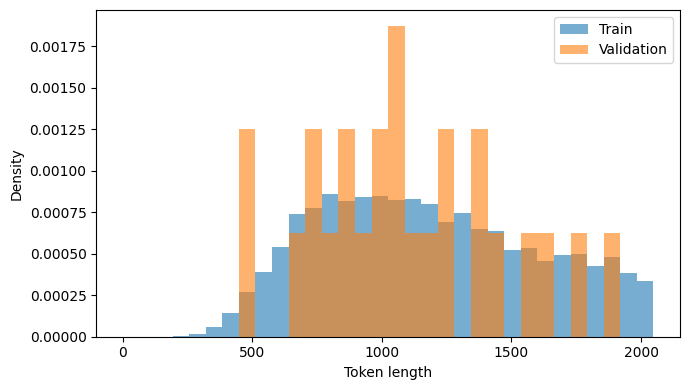

In [7]:
import matplotlib.pyplot as plt

train_lengths = [len(ex["token_ids"]) for ex in train_examples]
val_lengths = [len(ex["token_ids"]) for ex in val_examples]

# Normalize counts because the validation split is much smaller
bins = range(0, max(train_lengths + val_lengths) + 64, 64)

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(train_lengths, bins=bins, density=True, alpha=0.6, label="Train")
ax.hist(val_lengths, bins=bins, density=True, alpha=0.6, label="Validation")
ax.set_xlabel("Token length")
ax.set_ylabel("Density")
ax.legend()
plt.tight_layout()
plt.savefig("1.pdf")
plt.show()

- 验证样本数量少得多，因此验证直方图看起来有些锯齿状，但我们可以看到，它具有良好的分布覆盖。

&nbsp;
## 练习 8.2：不使用 `` 令牌进行蒸馏

` tokens" is tricky - the tokens themselves are code-like but part of the instruction text. Since they're enclosed in backticks, they should be treated as inline code and not translated. The rest of the sentence can be naturally translated to Chinese technical documentation style.

The translation should maintain the original markdown structure exactly, including the code block formatting and line breaks. No additional explanations are needed as per the user's request.</think>- 要在脚本执行命令中复现不包含 `

- 然后，在评估阶段，我们使用 `base` 模型而非 `reasoning` 模型：

```bash
uv run evaluate_math500.py \
--dataset_size 500 \
--which_model base \
--max_new_tokens 4096 \
--checkpoint_path run_11/checkpoints/distill/qwen3-0.6B-distill-step05746-epoch1.pth
```

- 新结果（不含思考标记）首先展示，对应的思考标记结果以括号形式呈现

| 教师数据                          | 轮次 | MATH-500 准确率 | 最终验证损失         |
|-----------------------------------|-----:|----------------:|---------------------:|
| 基础模型（第3章）                  |    - | 15.2%           |              -       |
| 推理模型（第3章）                  |    - | 48.2%           |              -       |
| DeepSeek R1 蒸馏数据              |    1 | 31.8% (30.6%)   | 0.5436   (0.5404)    |
| DeepSeek R1 蒸馏数据              |    2 | 31.8% (32.4%)   | 0.5349   (0.5339)    |
| DeepSeek R1 蒸馏数据              |    3 | 30.2% (33.6%)   | 0.5343   (0.5306)    |
| Qwen3 235B A22B 蒸馏数据          |    1 | 44.8% (45.0%)   | 0.4043   (0.3130)    |
| Qwen3 235B A22B 蒸馏数据          |    2 | 39.4% (43.8%)   | 0.3963   (0.3087)    |
| Qwen3 235B A22B 蒸馏数据          |    3 | 39.8% (44.2%)   | 0.3948   (0.3078)    |

` must remain unchanged as per the rules.</think>- 有趣的是，当省略 `